In [1]:
#1.Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="Inconsistent values: penalty=.*"
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

In [2]:
#2. Load the dataset
df = pd.read_csv("Training_Dataset.csv")

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())

# Display statistical summary
print(df.describe())

   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  popUpWidnow  Iframe  \

In [3]:
#3. Check the data target variable and missing value
print("Result distribution:")
print(df['Result'].value_counts())

print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Result distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64
Missing values:
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index     

In [4]:
#4 Separate data into X(Features the model uses to make a prediction) and Y(Target variable)

# X contains the 30 website features
X = df.drop(['Result'], axis=1)

# y contains the target variable
y = df['Result']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X:
   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  RightClick  popUpWi

In [5]:
#5 Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8844, 30)
X_test shape: (2211, 30)
y_train shape: (8844,)
y_test shape: (2211,)


6.Data Preparation, Modeling & Evaluation

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9284269815244445
Best Logistic Regression Model:
LogisticRegression(C=1, max_iter=200, penalty='l2', solver='liblinear')
First 20 predicted values:
[-1 -1 -1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1 -1 -1 -1]

First 20 actual values:
[-1 -1 -1  1  1  1  1 -1 -1 -1  1  1  1  1  1 -1  1 -1  1 -1]
Accuracy: 0.9240162822252375

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix:
[[ 864   92]
 [  76 1179]]


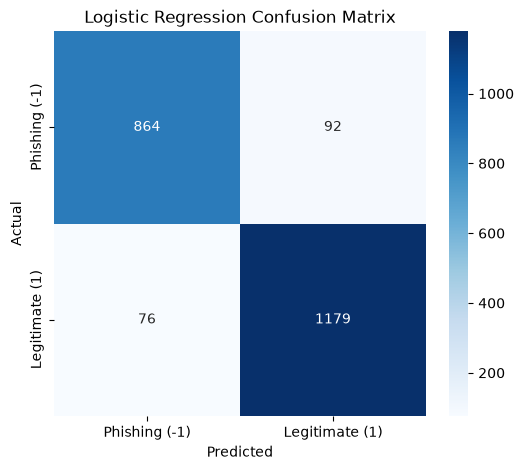

In [6]:
#6.1 Logistic Regression

# Base model
LR = LogisticRegression(max_iter=200)

# Define hyperparameter grid
param_grid = {
 'C': [0.01, 0.1, 1, 10, 100], # Regularization strength (smaller = stronger)
 'penalty': ['l1', 'l2'], # Regularization type
 'solver': ['liblinear', 'saga'], # Compatible solvers
}

#Perform 5-fold GridSearchCV
grid = GridSearchCV(
    estimator=LR,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

#Check the best parameters
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

#Get the best Logistic Regression model
best_model = grid.best_estimator_
print("Best Logistic Regression Model:")
print(best_model)

#Prediction
y_pred = best_model.predict(X_test)
print("First 20 predicted values:")
print(y_pred[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20])

#Evaluate logistic Regression
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Phishing (-1)', 'Legitimate (1)'],yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [7]:
# Feature Selection using Recursive Feature Elimination with Cross-Validation (RFECV)

# Base Logistic Regression model used for feature selection
selector_model = LogisticRegression(
    max_iter=200,
    solver='liblinear'
)

#Use Logistic Regression to evaluate feature importance
# RFECV will recursively removes the least important feature, one at a time, until only 1 feature remains.
# Then it uses 5-fold cross-validation accuracy to determine the optimal number of features to select.
rfecv = RFECV(
    estimator=selector_model,
    step=1,              # Remove 1 feature at a time
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  #Compare feature subses using accuracy
    n_jobs=-1            #Use all available CPU cores
)

# Perform RFECV feature selection on the training data
rfecv.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[rfecv.support_]
print("Optimal Number of Features:", rfecv.n_features_)
print("\nSelected Features:")
for feature in selected_features:
    print(feature)

# Get unselected feature names
unselected_features = X_train.columns[~rfecv.support_]
print("\nUnselected Features:")
for feature in unselected_features:
    print(feature)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("\nOriginal number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

Optimal Number of Features: 29

Selected Features:
having_IP_Address
URL_Length
Shortining_Service
having_At_Symbol
double_slash_redirecting
Prefix_Suffix
having_Sub_Domain
SSLfinal_State
Favicon
port
HTTPS_token
Request_URL
URL_of_Anchor
Links_in_tags
SFH
Submitting_to_email
Abnormal_URL
Redirect
on_mouseover
RightClick
popUpWidnow
Iframe
age_of_domain
DNSRecord
web_traffic
Page_Rank
Google_Index
Links_pointing_to_page
Statistical_report

Unselected Features:
Domain_registeration_length

Original number of features: 30
Selected number of features: 29


Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9284269175774845
Best Logistic Regression Model:
LogisticRegression(C=1, max_iter=200, penalty='l1', solver='liblinear')
Accuracy: 0.9240162822252375

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix:
[[ 863   93]
 [  75 1180]]


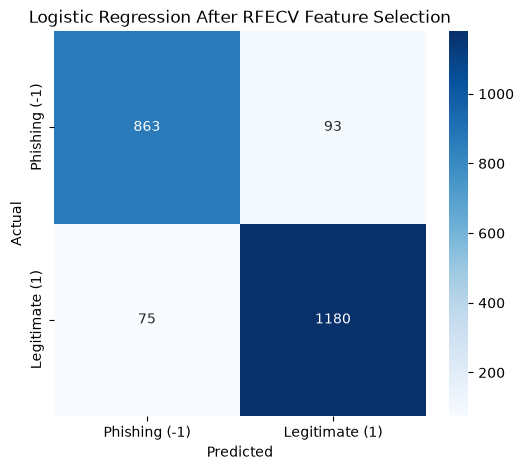

In [8]:
# Logistic Regression after Feature Selection

LR_selected = LogisticRegression(max_iter=200)

# Define hyperparameter grid
param_grid_selected = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

#Perform 5-fold GridSearchCV
grid_selected = GridSearchCV(
    estimator=LR_selected,
    param_grid=param_grid_selected,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_selected.fit(X_train_selected, y_train)

#Check the best parameters
print("Best Parameters:", grid_selected.best_params_)
print("Best Cross-Validation Accuracy:", grid_selected.best_score_)

#Get the best Logistic Regression model
best_model_selected = grid_selected.best_estimator_
print("Best Logistic Regression Model:")
print(best_model_selected)

#Prediction
y_pred_selected = best_model_selected.predict(X_test_selected)

#Evaluate logistic Regression
#Accuracy
accuracy_selected = accuracy_score(y_test, y_pred_selected)
print("Accuracy:", accuracy_selected)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected))

#Confusion matrix
cm_selected = confusion_matrix(y_test,y_pred_selected)
print("Confusion Matrix:")
print(cm_selected)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_selected,annot=True,fmt='d',cmap='Blues',xticklabels=['Phishing (-1)', 'Legitimate (1)'],yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression After RFECV Feature Selection")
plt.show()

In [9]:
#Compare original Logistic Regression against the selected-feature version
print("Logistic Regression Comparison")
print("--------------------------------")
print("Before Feature Selection:")
print("Number of Features:", X_train.shape[1])
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nAfter RFECV Feature Selection:")
print("Number of Features:", X_train_selected.shape[1])
print(f"Accuracy: {accuracy_selected * 100:.2f}%")

Logistic Regression Comparison
--------------------------------
Before Feature Selection:
Number of Features: 30
Accuracy: 92.40%

After RFECV Feature Selection:
Number of Features: 29
Accuracy: 92.40%
